### Google Colab에 Java 환경 세팅

In [ ]:
# Java 설치
!apt-get update -q
!apt-get install -y openjdk-17-jdk-headless

# 환경 변수 설정
import os
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-17-openjdk-amd64'
os.environ['PATH'] += ':/usr/lib/jvm/java-17-openjdk-amd64/bin'

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:2 https://cli.github.com/packages stable InRelease
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.6 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,201 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,510 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:13 http://security.ubuntu.com/ubuntu jammy-secu

### 문장 토큰 수 확인

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/371k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

[문장 35145] 아이스아메리카노 하나요
  → 토큰: ['▁아이', '스', '아', '메', '리', '카', '노', '▁하나', '요']
[문장 35147] 네 텀블러에 넣어주세요
  → 토큰: ['▁네', '▁', '텀', '블', '러', '에', '▁넣어', '주세요']
[문장 35148] 그란데 사이즈로 주세요
  → 토큰: ['▁그', '란', '데', '▁사이', '즈', '로', '▁', '주세요']
[문장 35151] 저 카푸치노로 주문할게요
  → 토큰: ['▁저', '▁카', '푸', '치', '노', '로', '▁주문', '할', '게', '요']
[문장 35154] 그럼 2000원 추가해서 브레드도 같이 시킬게요
  → 토큰: ['▁그', '럼', '▁2000', '원', '▁추가', '해서', '▁브', '레드', '도', '▁같이', '▁', '시킬', '게', '요']
[문장 35155] 저 도장 다 모았는데 나중에 써도 되나요?
  → 토큰: ['▁저', '▁', '도', '장', '▁다', '▁모', '았', '는데', '▁나중에', '▁써', '도', '▁되', '나', '요', '?']
[문장 35156] 이 기프티콘 여기서 사용할 수 있나요?
  → 토큰: ['▁이', '▁기', '프', '티', '콘', '▁여기', '서', '▁사용할', '▁수', '▁있', '나', '요', '?']
[문장 35157] 그럼 이 기프티콘 쓰고 다른걸로 주문할게요
  → 토큰: ['▁그', '럼', '▁이', '▁기', '프', '티', '콘', '▁쓰', '고', '▁다른', '걸', '로', '▁주문', '할', '게', '요']
[문장 35159] 자바칩 프라푸치노에 휘핑 빼고요
  → 토큰: ['▁자', '바', '칩', '▁', '프라', '푸', '치', '노', '에', '▁휘', '핑', '▁빼', '고', '요']
[문장 35160] 여기 기프티콘 대면 되죠?
  → 토큰: ['▁여기', '▁기', '프', '티'

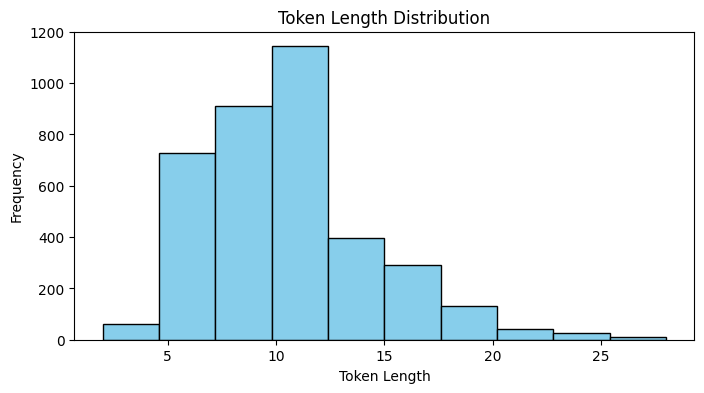

In [ ]:
from transformers import AutoTokenizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tokenizer = AutoTokenizer.from_pretrained('skt/kobert-base-v1', use_fast=False)

df = pd.read_csv('./dialog_data.csv')
cafe_df = df[(df['SPEAKER'] == '고객') & (df['DOMAIN'] == '카페')].copy()

cafe_df['TOKENS'] = cafe_df['SENTENCE'].apply(lambda x: tokenizer.tokenize(x))
cafe_df['TOKEN_LENGTH'] = cafe_df['TOKENS'].apply(len)
for i, (sent, tokens) in cafe_df[['SENTENCE', 'TOKENS']].head(10).iterrows():
    print(f'[문장 {i}] {sent}')
    print(f'  → 토큰: {tokens}')

# 통계 정보 출력
token_lengths = cafe_df['TOKEN_LENGTH']
print(f'총 문장 수: {len(token_lengths)}')
print(f'최대 토큰 길이: {token_lengths.max()}')
print(f'평균 토큰 길이: {token_lengths.mean():.2f}')
print(f'95th 백분위수(상위 10% 컷): {np.percentile(token_lengths, 90)}')
print(f'95th 백분위수(상위 5% 컷): {np.percentile(token_lengths, 95)}')
print(f'99th 백분위수(상위 1% 컷): {np.percentile(token_lengths, 99)}')

# 길이 분포 시각화
plt.figure(figsize=(8,4))
plt.hist(token_lengths, color='skyblue', edgecolor='black')
plt.title('Token Length Distribution')
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.show()


In [ ]:
!pip install prettytable
!pip install koeda

import random

import pandas as pd
import torch
import torch.nn as nn
from koeda import EasyDataAugmentation, RandomSwap, RandomDeletion, SynonymReplacement, RandomInsertion
from prettytable import PrettyTable
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
from transformers import AutoTokenizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 133.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 46.0 MB/s eta 0:00:00
  Attempting uninstall: tweepy
    Found existing installation: tweepy 4.16.0
    Uninstalling tweepy-4.16.0:
      Successfully uninstalled tweepy-4.16.0
True


In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_accuracy = 0.0
        self.counter = 0
        self.best_model = None

    def __call__(self, accuracy, model):
        if accuracy > self.best_accuracy + self.min_delta:
            self.best_accuracy = accuracy
            self.counter = 0
            self.best_model = model.state_dict()
        else:
            self.counter += 1
        return self.counter >= self.patience

In [ ]:
class IntentDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=64):
        self.sentences = df['SENTENCE'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):  # Dataset 크기 (샘플 개수) 반환
        return len(self.sentences)

    def __getitem__(self, idx):
        sentence = self.sentences[idx]

        encoding = self.tokenizer(
            sentence,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [ ]:
class TransformerEncoderClassifier(nn.Module):
    def __init__(self, vocab_size, pad_id, num_classes, d_model=256, nhead=4, num_layers=3, dim_feedforward=512,
                 max_len=64, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout,
                                                   batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)

        self.layer_norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, input_ids, attention_mask=None):
        batch_size, seq_len = input_ids.size()
        pos = torch.arange(0, seq_len, device=input_ids.device).unsqueeze(0).expand(batch_size, seq_len)

        x = self.embedding(input_ids) + self.pos_embedding(pos)
        x = self.encoder(x, src_key_padding_mask=(attention_mask == 0))

        x = x[:, -1]
        x = self.layer_norm(x)
        return self.classifier(x)

In [ ]:
def augment_dataframe(df, num_aug=1):
    swap = RandomSwap(morpheme_analyzer='Okt')
    delete = RandomDeletion(morpheme_analyzer='Okt')
    new_data = []
    for _, row in df.iterrows():
        sentence = row['SENTENCE']
        label = row['label']
        new_data.append({'SENTENCE': sentence, 'label': label})
        for _ in range(num_aug):
            new_data.append({'SENTENCE': swap(sentence, 0.0), 'label': label})
            new_data.append({'SENTENCE': delete(sentence, 0.2), 'label': label})
    return pd.DataFrame(new_data)

In [ ]:
def get_data_loader(tokenizer, batch_size=64, max_length=64, num_aug=1):
    df = pd.read_csv('./dialog_data.csv')
    cafe_df = df[(df['SPEAKER'] == '고객') & (df['DOMAIN'] == '카페')].copy()
    cafe_df = cafe_df[['SENTENCE', 'MAIN_GROUPED']].copy()

    # Data 증강
    augmented_df = pd.read_csv('./dialog_data_augmented.csv')
    cafe_df = pd.concat([cafe_df, augmented_df], ignore_index=True)

    # label encoding
    label_encoder = LabelEncoder()
    cafe_df['label'] = label_encoder.fit_transform(cafe_df['MAIN_GROUPED'])
    print(cafe_df)
    cafe_df = cafe_df[['SENTENCE', 'label']].copy()

    cafe_train, cafe_val = train_test_split(cafe_df, test_size=0.2, random_state=42, stratify=cafe_df['label'])
    print(cafe_train)

    cafe_train = augment_dataframe(cafe_train, num_aug)
    print(cafe_train)

    train_dataset = IntentDataset(cafe_train, tokenizer, max_length)
    val_dataset = IntentDataset(cafe_val, tokenizer, max_length)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=1, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=1, pin_memory=True)

    return train_loader, val_loader, len(label_encoder.classes_)

In [ ]:
def analyze_model_parameters(model):
    table = PrettyTable(['Layer Name', 'Parameter Count', 'Shape'])
    total_params = 0

    for name, parameter in model.named_parameters():
        if parameter.requires_grad:
            params = parameter.numel()
            table.add_row([name, f'{params:,}', str(list(parameter.shape))])
            total_params += params

    print(table)
    print(f'\n전체 훈련 가능한 파라미터: {total_params:,}')

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * input_ids.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

In [ ]:
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, mask)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * input_ids.size(0)
            predicted = outputs.argmax(dim=1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

In [ ]:
def train_models(device, batch_size, d_model, nhead, num_layers, dim_feedforward, dropout, label_smoothing,
                 learning_rate, weight_decay, num_aug, epochs, max_length=32):

    early_stopping = EarlyStopping(400, 0)

    # HuggingFace KoBERT tokenizer 사용
    tokenizer = AutoTokenizer.from_pretrained('skt/kobert-base-v1', use_fast=False)

    train_loader, val_loader, num_classes = get_data_loader(tokenizer, batch_size, max_length, num_aug)

    model = TransformerEncoderClassifier(
        vocab_size=len(tokenizer), pad_id=tokenizer.pad_token_id, num_classes=num_classes,
        d_model=d_model, nhead=nhead, num_layers=num_layers,
        dim_feedforward=dim_feedforward, max_len=max_length, dropout=dropout
    ).to(device)

    # Model 정보 출력
    analyze_model_parameters(model)

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    writer = SummaryWriter(f'./intent-classification-tf')  # TensorBoard 설정

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = eval_epoch(model, val_loader, criterion, device)

        writer.add_scalars('loss', {'train': train_loss, 'validation': val_loss}, epoch + 1)
        writer.add_scalars('accuracy', {'train': train_acc, 'validation': val_acc}, epoch + 1)
        print(f' Epoch {epoch + 1}: train_loss={train_loss:.4f} acc={train_acc:.4f} '
              f'| val_loss={val_loss:.4f} acc={val_acc:.4f}')

        # Check early stopping condition
        if early_stopping(val_acc, model):
            print('Early stopping triggered.')
            break

    print(f'Training finished. Best Accuracy: {early_stopping.best_accuracy:.4f}')
    writer.close()  # TensorBoard 종료
    torch.save(early_stopping.best_model, './cafe_only.pt')

In [ ]:
experiment_sets = [
    {
        'num_layers': 2,
        'nhead': 4,
        'd_model': 512,
        'dim_feedforward': 512,
        'learning_rate': 1e-5,
        'weight_decay': 1e-4,
        'label_smoothing': 0.3,
        'dropout': 0.4,
        'batch_size': 64,
        'num_aug': 4,
        'epochs': 400
    },
]

for i, params in enumerate(experiment_sets):
    print(f'\n🔹 [Experiment {i + 1}/{len(experiment_sets)}] Params: {params}')
    train_models(device=device, **params)


🔹 [Experiment 1/1] Params: {'num_layers': 2, 'nhead': 4, 'd_model': 512, 'dim_feedforward': 512, 'learning_rate': 1e-05, 'weight_decay': 0.0001, 'label_smoothing': 0.3, 'dropout': 0.4, 'batch_size': 64, 'num_aug': 4, 'epochs': 400}
                         SENTENCE MAIN_GROUPED  label
0                    아이스아메리카노 하나요         일반주문     70
1                    네 텀블러에 넣어주세요        텀블러사용     90
2                    그란데 사이즈로 주세요         일반주문     70
3                   저 카푸치노로 주문할게요         일반주문     70
4      그럼 2000원 추가해서 브레드도 같이 시킬게요         결제요청      4
...                           ...          ...    ...
12408               휴지 추가로 부탁드려요.         휴지요구    111
12409        휴지 조금 더 챙겨주실 수 있으세요?         휴지요구    111
12410             휴지 더 가져갈 수 있나요?         휴지요구    111
12411       휴지 한 장 더 챙겨주시면 안 될까요?         휴지요구    111
12412             휴지 더 주실 수 있을까요?         휴지요구    111

[12413 rows x 3 columns]
                     SENTENCE  label
9810     테이크아웃으로 한 거 취소해 주세요.     79
11165              

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


+--------------------------------------------+-----------------+-------------+
|                 Layer Name                 | Parameter Count |    Shape    |
+--------------------------------------------+-----------------+-------------+
|              embedding.weight              |    4,097,024    | [8002, 512] |
|            pos_embedding.weight            |      16,384     |  [32, 512]  |
| encoder.layers.0.self_attn.in_proj_weight  |     786,432     | [1536, 512] |
|  encoder.layers.0.self_attn.in_proj_bias   |      1,536      |    [1536]   |
| encoder.layers.0.self_attn.out_proj.weight |     262,144     |  [512, 512] |
|  encoder.layers.0.self_attn.out_proj.bias  |       512       |    [512]    |
|      encoder.layers.0.linear1.weight       |     262,144     |  [512, 512] |
|       encoder.layers.0.linear1.bias        |       512       |    [512]    |
|      encoder.layers.0.linear2.weight       |     262,144     |  [512, 512] |
|       encoder.layers.0.linear2.bias        |      

  0%|          | 1/400 [00:40<4:31:28, 40.82s/it]

 Epoch 1: train_loss=4.5673 acc=0.0899 | val_loss=4.2095 acc=0.1542


...

 Epoch 398: train_loss=2.1256 acc=0.9704 | val_loss=2.6798 acc=0.8091


100%|█████████▉| 399/400 [4:21:57<00:39, 39.11s/it]

 Epoch 399: train_loss=2.1269 acc=0.9691 | val_loss=2.6820 acc=0.8095


100%|██████████| 400/400 [4:22:36<00:00, 39.39s/it]

 Epoch 400: train_loss=2.1246 acc=0.9706 | val_loss=2.6794 acc=0.8119
Training finished. Best Accuracy: 0.8192


In [ ]:
# TensorBoard 결과 출력
%load_ext tensorboard
%tensorboard --logdir=./

In [ ]:
from google.colab import runtime
import time

time.sleep(30)
runtime.unassign()